In [1]:
import pandas as pd 
import sys 
sys.path.append('../src')
from data.preprocessing import prepare_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
#charger la data brute 
data_brute = pd.read_json('../data/raw/News_Category_Dataset_v3.json', lines=True)

data_brute.head()


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [3]:
data_brute.info()

<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  str           
 1   headline           209527 non-null  str           
 2   category           209527 non-null  str           
 3   short_description  209527 non-null  str           
 4   authors            209527 non-null  str           
 5   date               209527 non-null  datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 71.2 MB


In [4]:
data_clean,encoder=prepare_dataset(data_brute)
data_clean.head()

,link,headline,category,short_description,authors,date,category_original,text,cleaned_text,text_length,word_count,year,month,day,category_encoded
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,News & Politics,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...,over 4 million americans roll up sleeves for o...,231,40,2022,9,23,10
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",News & Politics,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li...",american airlines flyer charged banned for lif...,249,41,2022,9,23,10
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,Entertainment,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,23 of the funniest tweets about cats and dogs ...,134,25,2022,9,23,3
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,Family,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,PARENTING,The Funniest Tweets From Parents This Week (Se...,the funniest tweets from parents this week sep...,216,34,2022,9,23,5
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,News & Politics,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...,woman who called cops on black birdwatcher los...,234,36,2022,9,22,10


In [5]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 209514 entries, 0 to 209526
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209514 non-null  str           
 1   headline           209514 non-null  str           
 2   category           209514 non-null  str           
 3   short_description  209514 non-null  str           
 4   authors            209514 non-null  str           
 5   date               209514 non-null  datetime64[us]
 6   category_original  209514 non-null  str           
 7   text               209514 non-null  str           
 8   cleaned_text       209514 non-null  str           
 9   text_length        209514 non-null  int64         
 10  word_count         209514 non-null  int64         
 11  year               209514 non-null  int32         
 12  month              209514 non-null  int32         
 13  day                209514 non-null  int32         
 14  cate

In [6]:
data_clean["category"].value_counts()

category
News & Politics    50082
Lifestyle          34721
Entertainment      25539
Health             24636
Family             19825
identity           15631
Business            7748
Media & Impact      6428
Sports              5077
Science & Tech      4306
Environment         4065
Arts & Culture      3922
Good News           2799
Religion            2577
Education           2158
Name: count, dtype: int64

In [7]:
data_clean.to_csv('../data/processed/data_clean.csv', index=False)

In [8]:
x=data_clean["cleaned_text"]
y=data_clean["category_encoded"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y
                                               )#   stratify=y pour garder la même proportions des classes dans les sets d'entraînement et de test

In [10]:
models={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [11]:
#entrainer et comparer les modeles
Results=[]
best_f1=0
best_pipeline=None
best_model_name=""
for model_name, model in models.items():

    pipeline = Pipeline([
        ("tfidf",TfidfVectorizer(
    max_features=20000,#garder les 20 000 mots les plus fréquents
    stop_words="english",#ignorer les mots vides en anglais comme "the", "is", "in"...
    ngram_range=(1, 2)  #utiliser des unigrammes et des bigrammes
)),
        ("model", model)
    ])

    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')#macro pour calculer le f1 score pour chaque classe et faire la moyenne sans tenir compte du déséquilibre des classes

    #sauvegarder le meilleur modèle
    if f1 > best_f1:
        best_f1 = f1
        best_pipeline = pipeline
        best_model_name = model_name

    Results.append({
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1
    })

    print("=" * 30)
    print(f"Model: {model_name}")
    print(f"Accuracy: {acc}")
    print(f"F1 Score: {f1}")
    print(classification_report(y_test, y_pred))

Model: Logistic Regression
Accuracy: 0.708922988807484
F1 Score: 0.5564696176488325
              precision    recall  f1-score   support

           0       0.68      0.37      0.47       784
           1       0.64      0.48      0.55      1550
           2       0.54      0.34      0.42       432
           3       0.65      0.72      0.68      5108
           4       0.57      0.32      0.41       813
           5       0.74      0.76      0.75      3965
           6       0.61      0.12      0.19       560
           7       0.69      0.79      0.74      4927
           8       0.76      0.86      0.81      6944
           9       0.56      0.27      0.37      1286
          10       0.74      0.87      0.80     10017
          11       0.70      0.36      0.48       515
          12       0.65      0.37      0.47       861
          13       0.74      0.60      0.66      1015
          14       0.64      0.49      0.55      3126

    accuracy                           0.71     41

In [12]:
results_df = pd.DataFrame(Results)
results_df.sort_values(by="f1_macro", ascending=False)

,model,accuracy,f1_macro
1,Linear SVM,0.704985,0.568380
0,Logistic Regression,0.708923,0.556470
3,Random Forest,0.631649,0.439427
2,Multinomial Naive Bayes,0.662124,0.395155


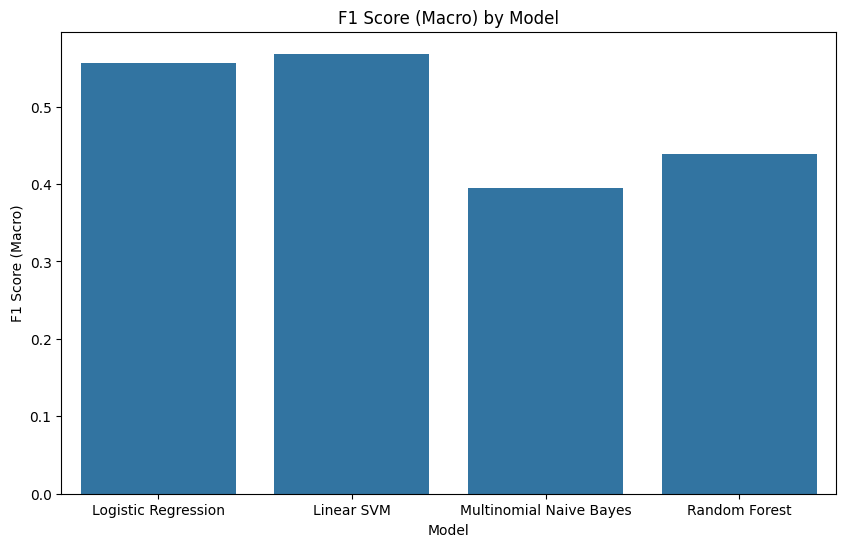

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="f1_macro", data=results_df)
plt.title("F1 Score (Macro) by Model")
plt.ylabel("F1 Score (Macro)")
plt.xlabel("Model")
plt.show()

In [14]:
print("Best Model:", best_model_name)

y_pred_best = best_pipeline.predict(x_test)

cm=confusion_matrix(y_test, y_pred_best)

Best Model: Linear SVM


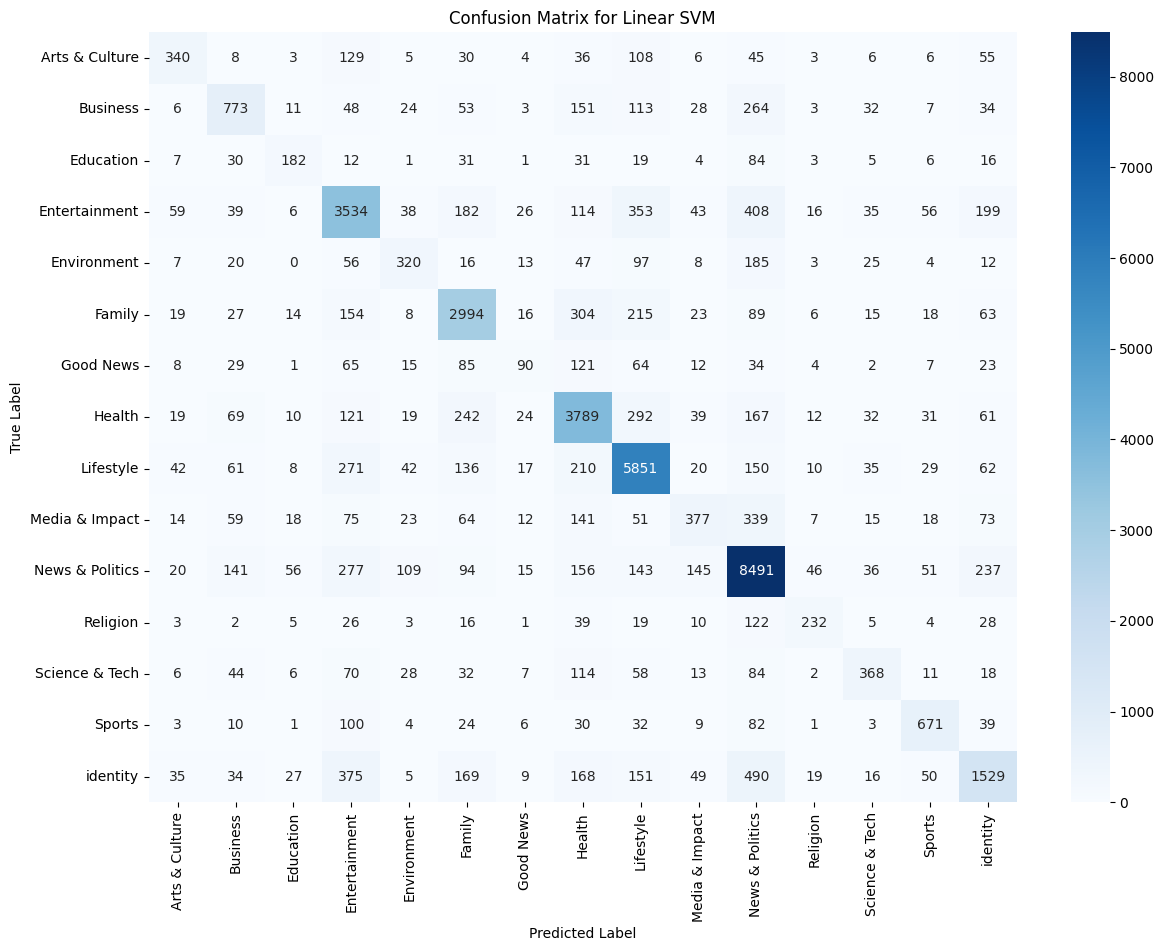

In [15]:
class_names=encoder.classes_
plt.figure(figsize=(14, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix for {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()